<a href="https://colab.research.google.com/github/PolinaRybalko/Website-performance-exploration-analysis/blob/main/Portfolio_Website_Performance_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Portfolio project "Website performance analysis: Market Growth Opportunity"

Portfolio project done by Polina Rybalko-Ohanjanyan. It consists of an  exploratory data analysis of the web sessions of IKEA of 3 months, from which a business opportunity was derived.

The project is split into 6 chapters:
1. **Setting up the data.** This is where I connect to the big query database, execute a query and store the result in pandas data frame.
2. **Cleaning the data** Cleaning duplicate rows, missing data, data types and categorical columns formatting type.
3. **Business context** The general structure of the data.
4. **Exploration overview** At the beginning of the section there is a conclusion and business questions that arised during the section.
5. **Business question** The questions that emerged during the exploration.
6. **Deeper analysis** In this section I explore the specific business questions I chose after initial exploration. Each question has a specific section inside this chapter, that is answered with the data.
7. **Key findings, recommendations, limitations and Next Steps** Short summary of the analysis, my conclusions and business recommendations, followed by limitations and next steps in investigation.

Additional visualizations can be found on the following dashboards in Tableau: https://public.tableau.com/app/profile/polina.rybalko.ohandzhanian/viz/Portfolio1_17889018093380/Salesconcentrationanalysis?publish=yes

#1. Setting up the data

In [166]:
#!pip install --upgrade google-cloud-bigquery
!pip install adjustText

from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Authentication
auth.authenticate_user()

# Creating a BigQuery client
client = bigquery.Client(project="data-analytics-mate")

# SQL query
query = """
WITH
  orders_with_prices AS (
    SELECT
      o.ga_session_id,
      o.item_id,
      p.price,
      p.name,
      p.category,
      p.short_description
    FROM `DA.order` o
    JOIN `DA.product` p
      ON o.item_id = p.item_id
  ),
  users_data AS (
    SELECT
      accs.ga_session_id,
      accs.account_id,
      1 - a.is_unsubscribed AS is_subscribed,
      a.is_verified
    FROM `DA.account_session` accs
    JOIN `DA.account` a
      ON accs.account_id = a.id
  )
SELECT
  date,
  s.ga_session_id,
  o.item_id,
  o.price,
  o.name,
  o.category,
  o.short_description,
  sp.device,
  sp.country,
  sp.continent,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.medium AS traffic_medium,
  sp.channel AS traffic_channel,
  ud.account_id AS user_id,
  ud.is_subscribed,
  ud.is_verified
FROM `DA.session` s
JOIN `DA.session_params` sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN orders_with_prices o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN users_data ud
  ON ud.ga_session_id = s.ga_session_id
"""

# Executing the query
query_job = client.query(query)  # Executing the SQL query
results = query_job.result()  # Waiting for the query to complete

# Converting the results to a DataFrame
data = results.to_dataframe(create_bqstorage_client=False)

# Displaying the result
data.head()

,date,ga_session_id,item_id,price,name,category,short_description,device,country,continent,browser,mobile_model_name,operating_system,language,traffic_medium,traffic_channel,user_id,is_subscribed,is_verified
0,2020-11-01,5760483956,99902661,609.0,VITTSJÖ,Bookcases & shelving units,"Shelving unit with laptop table, 202x36x175 cm",desktop,United States,Americas,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>
1,2020-11-01,7115337200,99902661,609.0,VITTSJÖ,Bookcases & shelving units,"Shelving unit with laptop table, 202x36x175 cm",desktop,United Kingdom,Europe,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>
2,2020-11-01,3978035233,20382932,189.0,RÅSKOG,Tables & desks,"Trolley, 35x45x78 cm",mobile,Norway,Europe,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>
3,2020-11-01,9648986282,99902661,609.0,VITTSJÖ,Bookcases & shelving units,"Shelving unit with laptop table, 202x36x175 cm",mobile,Nigeria,Africa,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>
4,2020-11-01,4393441533,99902661,609.0,VITTSJÖ,Bookcases & shelving units,"Shelving unit with laptop table, 202x36x175 cm",desktop,China,Asia,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>


#2. Cleaning the data

2.1. Checking for dublicates

2.2. Check for missing values

2.3. Check for wrong data type and anomalies

##2.1. Checking for dublicates

In [167]:
#1.1 Checking for dublicates

print("The number of dublicated rows:", data.duplicated().sum())

The number of dublicated rows: 0


##2.2. Check for missing values

In [168]:
#1.2 Check for missing values

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   item_id            33538 non-null   Int64  
 3   price              33538 non-null   float64
 4   name               33538 non-null   object 
 5   category           33538 non-null   object 
 6   short_description  33538 non-null   object 
 7   device             349545 non-null  object 
 8   country            349545 non-null  object 
 9   continent          349545 non-null  object 
 10  browser            349545 non-null  object 
 11  mobile_model_name  349545 non-null  object 
 12  operating_system   349545 non-null  object 
 13  language           235279 non-null  object 
 14  traffic_medium     349545 non-null  object 
 15  traffic_channel    349545 non-null  object 
 16  us

item_id, price, name and category were only present in order table, that was joined with the session table by ga_session_id, and that's why the number of sessions item_id  equals the number of orders.


In every order in the order table there was only 1 product listed as ordered, and therefore the revenue from the order is equal to the price of the product. Each session in the data had only one order associated with it or none.


Same with user_id, is_subscrived and is_verified: these fields were taken from account table, and were only present for those sessions that had an account associated with them.

There are 18 columns and 349545 rows in our data.
Columns user_id, is_subscribed, is_verified have data in them only for registered users so they have the least amount of data - 27945 entries.
Columns item_id, price, name, category are only for sessions with orders, so they have 33538 rows.

## 2.3. Check for wrong data type and anomalies

In 1.2 we can see information about the type of the column. Most of the columns' types are correctly identified (12), and 6 need to be assigned the type manually:
* `date` was assigned dbdate type, which will not be compatible with the visualisation libraries later on, so we will convert to pandas native date type datetime.
* `ga_session_id`, `item_id`, `user_id` are strings, not numbers
* `is_subscribed` and `is_verified` are booleans.

In [169]:
# 1.3 manually assigning user_id to string and is_subscribed and is_verified to boolean

data['date'] = pd.to_datetime(data['date'])

data['ga_session_id'] = data['ga_session_id'].astype('string')
data['item_id'] = data['item_id'].astype('string')
data['user_id'] = data['user_id'].astype('string')

data['is_subscribed'] = data['is_subscribed'].astype('boolean')
data['is_verified'] = data['is_verified'].astype('boolean')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               349545 non-null  datetime64[ns]
 1   ga_session_id      349545 non-null  string        
 2   item_id            33538 non-null   string        
 3   price              33538 non-null   float64       
 4   name               33538 non-null   object        
 5   category           33538 non-null   object        
 6   short_description  33538 non-null   object        
 7   device             349545 non-null  object        
 8   country            349545 non-null  object        
 9   continent          349545 non-null  object        
 10  browser            349545 non-null  object        
 11  mobile_model_name  349545 non-null  object        
 12  operating_system   349545 non-null  object        
 13  language           235279 non-null  object  

To detect data formating errors, we will look at all the possible values in the columns with categorical data.

In [170]:
not_included_columns = ['date', 'ga_session_id', 'item_id', 'user_id', 'price', 'short_description']

for col in data.columns:
  if col not in not_included_columns:
    print(col, data[col].unique())

name ['VITTSJÖ' 'RÅSKOG' 'GALANT' 'FRANKLIN' None 'MELLTORP / ADDE'
 'BESTÅ / EKET' 'EKET' 'STRANDMON' 'KIVIK' 'EKEDALEN / EKEDALEN'
 'LYCKSELE LÖVÅS' 'HANVIKEN' 'LÄCKÖ' 'FYRESDAL' 'LISABO / LEIFARNE'
 'ROTHULT' 'MAMMUT' 'LUNNARP' 'BEKANT' 'BESTÅ' 'JONAXEL' 'ELVARLI'
 'GRÖNLID' 'LIDHULT' 'BROR' 'KALLAX' 'FÄRLÖV' 'LINNMON / GODVIN' 'TROFAST'
 'LANGUR' 'HAVSTEN' 'LERHAMN' 'BORTBERG' 'VIMLE' 'ÄPPLARÖ' 'KUDDARNA'
 'VATTVIKEN' 'HAVSTA' 'SVÄRTA' 'KUNGSHAMN' 'FLOTTEBO' 'SUNDVIK' 'PÅHL'
 'KVISTBRO' 'STUVA / FRITIDS' 'FRIHETEN' 'NYHAMN' 'BROMMÖ' 'LIXHULT'
 'IVAR' 'SJÄLLAND' 'SYVDE' 'STOCKSUND' 'ANTILOP' 'BILLY / OXBERG'
 'LINNMON / LERBERG' 'FRÖSÖN' 'NOTVIKEN' 'BOLMEN' 'KOARP' 'GAMLARED'
 'KALLRÖR' 'ALEX' 'DELAKTIG' 'ALGOT' 'LINNMON / HILVER' 'SANDBACKEN'
 'NORBERG' 'ÖRFJÄLL' 'SLÄKT' 'DUVHOLMEN' 'BILLY / MORLIDEN' 'BRIMNES'
 'SANDARED' 'HATTEFJÄLL' 'MICKE' 'BAGGANÄS' 'SÖDERHAMN' 'MÄSTERBY' 'STUK'
 'EKERÖ' 'ÖSTERNÄS' 'LINNMON / KRILLE' 'DJUPVIK' 'HÄLLAN' 'SOLLERÖN'
 'NORDVIKEN / LEIFARNE' 'GAMLE

We see that in each columns there is a universal letter case, spacing and formatting. No errors in categorical data, that we can detect.

Next we will check our price data for anomalies.

In [171]:
data['price'].describe()

,price
count,33538.000000
mean,953.298679
std,1317.001775
min,3.000000
25%,170.000000
50%,445.000000
75%,1195.000000
max,9585.000000


The data range is consistent with the prices on the website.

#3. Business context

Main conclusions:


3.1 There are 349545 sessions in the dataset from the November 1st 2020 to January 31st 2021, among which 27945 (8%) are from registered users and 33538 (9.6%) of them are with an order. All the sessions are unique.

3.2 The sessions are from 107 countries from all the continents.

3.3 There were 551 products sold across 14 categories.

3.4 The sum of sales in the time period: 31971731.1

In [172]:
#3.1 sessions
print('3.1')
print('all sessions', data['ga_session_id'].shape[0])
print('from', data['date'].min(), 'to', data['date'].max())
total_users = data['user_id'].count()
print('from registered users', total_users, "," , total_users/data.shape[0] * 100, "%")
total_orders = data['item_id'].count()
print('with an order', total_orders, "," , total_orders/data.shape[0] * 100, "%")
print('duplicated sessions', data.duplicated(subset=['ga_session_id']).sum(), '\n')

#3.2 geography
print('3.2')
total_countries = data['country'].unique().shape[0] - 1 #one of the values in countries is (not set), so there are not 108, but 107 countries
print('number of countries:', total_countries)
print('continents:', data['continent'].unique(), '\n')

#3.3 products and categories
print('3.3')
print('number of products', data['name'].unique().shape[0])
print('number of categories:', data['category'].unique().shape[0] - 1, '\n') #one of the values in categories is None, so there are not 15, but 14 categories

#3.4 total sales and orders
print('3.4')
total_sales = data['price'].sum()
print('total sales', total_sales)
print('Average order value (AOV)', total_sales/total_orders, '\n')

print('3.5')
print('languages available:', data['language'].unique())

3.1
all sessions 349545
from 2020-11-01 00:00:00 to 2021-01-31 00:00:00
from registered users 27945 , 7.994678796721452 %
with an order 33538 , 9.594758900856828 %
duplicated sessions 0 

3.2
number of countries: 107
continents: ['Americas' 'Europe' 'Africa' 'Asia' 'Oceania' '(not set)'] 

3.3
number of products 551
number of categories: 14 

3.4
total sales 31971731.100000005
Average order value (AOV) 953.2986791102632 

3.5
languages available: ['zh' 'en-us' 'es-es' None 'en-gb' 'en-ca' 'fr' 'ko' 'en' 'de']


#4. Exploration overview

4.1. Main conclusion: USA, India and Canada constitute a large portion of the market by both sales and orders.

1. **What percentage of revenue do they constitute?**
2. **What countries would we put in A,B and C tiers of a geographical analysis?**
3. **How many countries are in each group?**

4.2 Main conclusion: The top-3 countries are leaders mostly because of the volume of orders, and not because they have the highest average order values.

4.3 Main conclusion: Top-5 countries don't have the highest conversion rates.

**Which markets underperform relative to their traffic? Which of them have the biggest financial gaps?**

## 4.1 Top markets by sales and orders

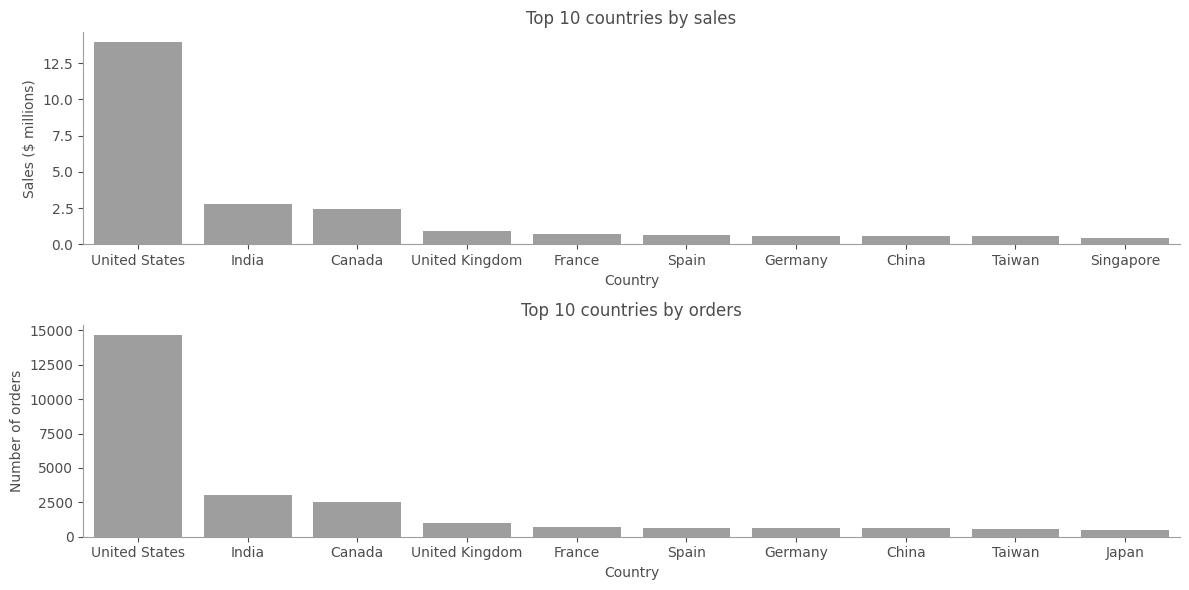

In [173]:
# Shared chart colors keep the portfolio visuals consistent across sections.
GRAY = '#9E9E9E'
DARK_GRAY = '#4D4D4D'
LIGHT_GRAY = '#D3D3D3'
ORANGE = '#BE5504'
BLUE = '#4C78A8'
BLACK = '#000000'

plt.rcParams.update({
    'text.color': DARK_GRAY,
    'axes.labelcolor': DARK_GRAY,
    'axes.titlecolor': DARK_GRAY,
    'xtick.color': DARK_GRAY,
    'ytick.color': DARK_GRAY,
    'legend.labelcolor': DARK_GRAY,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': GRAY,
})

countries_sales = data.groupby(['country'])['price'].sum()
countries_sales_sorted = countries_sales.sort_values(ascending=False)
countries_sales_sorted_df = countries_sales_sorted.reset_index()

countries_orders_count = data.groupby(['country'])['item_id'].count()
countries_orders_count_sorted = countries_orders_count.sort_values(ascending=False)
countries_orders_count_sorted_df = countries_orders_count_sorted.reset_index()

fig,axes = plt.subplots(2, 1, figsize=(12,6))
sns.barplot(data = countries_sales_sorted_df.head(10), x="country", y="price", ax=axes[0], color=GRAY)
sns.barplot(data = countries_orders_count_sorted_df.head(10), x="country", y="item_id", ax=axes[1], color=GRAY)

axes[0].set_title('Top 10 countries by sales')
axes[1].set_title('Top 10 countries by orders')
axes[0].set_xlabel('Country')
axes[1].set_xlabel('Country')
axes[0].set_ylabel('Sales ($ millions)')
axes[1].set_ylabel('Number of orders')

plt.tight_layout()

from matplotlib.ticker import FuncFormatter #importing the FuncFormatter

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}')) #using FuncFormatter to make our y ticks be measured in millions, not tens of millions

The top-9 countries in Sales and Orders are the same. The leading country is United States, then, almost 5 times less Sales and Orders have India and Canada. United Kingdom and France have about two times less sales and orders than India and Canada.

Next, let's look at specific numbers and percentages. Because the countries are so many, and USA, India and Canada constitute visually a large portion of total sales, the following questions arise: **What percentage of revenue do they constitute? What countries would we put in A,B and C tiers of a geographical analysis? How many countries are in each group?**  

##4.2 AOV

In 3.4 we see that the average order value is 953.3 $. Let's explore the AOV across the countries

In [174]:
countries_info = countries_sales_sorted_df.merge(countries_orders_count_sorted_df, how="inner", on="country")

countries_info = countries_info.rename(columns={'price': 'sales'})
countries_info['sales (in millions)'] = round(countries_info['sales']/1e6, 1)
countries_info['sales share'] = countries_info['sales']/total_sales

countries_sessions =  data.groupby(['country'])['ga_session_id'].count()
countries_info  = countries_info.set_index('country')
countries_info['ga_session_id'] = countries_sessions
countries_info = countries_info.reset_index()
countries_info = countries_info.rename(columns={'ga_session_id':'sessions', 'item_id' : 'orders'})

countries_info['CR'] = countries_info['orders']/countries_info['sessions']

countries_info['AOV'] = countries_info['sales']/countries_info['orders']
print(countries_info[['country', 'AOV']].sort_values(by= 'AOV',ascending=False).head(10))

       country          AOV
64   Palestine  1747.692308
50    Bulgaria  1518.111111
72     Albania  1401.500000
68   Venezuela  1396.769231
56       Kenya  1373.478261
96    Honduras  1372.200000
74        Oman  1357.770000
62     Algeria  1293.666667
53   Lithuania  1282.250000
60  Kazakhstan  1234.619048


We observe that the highest AOV countries are in the range from 53rd to 96th places among the top selling countries.

Let's look at the AOVs of the top-5 countries

In [175]:
top_5_countries = countries_info['country'].head(5) # a variable for the future calculations
top_5_countries_order = countries_info.sort_values(by = 'sales', ascending=False)['country'].head(5) # a variable for the future calculations

display(
    countries_info[countries_info["country"].isin(top_5_countries)][
        ["country", "AOV"]
    ]
    .set_index("country")
    .style.format({"AOV": "${:,.2f}"})
)

,AOV
country,
United States,$950.29
India,$927.62
Canada,$952.31
United Kingdom,$911.87
France,"$1,048.22"


**From the AOV we can deduce that these countries are leaders mostly because of the volume of orders, and not because they have the highest AOVs**

##4.3 Total sessions and conversion rate

,sessions,conversion rate
country,,
United States,"153,470",9.56%
India,"32,763",9.25%
Canada,"25,994",9.85%
United Kingdom,"11,003",9.35%
France,"6,958",9.74%
Spain,"6,505",10.12%
Germany,"6,196",10.36%
China,"6,066",9.89%
Taiwan,"5,879",9.59%


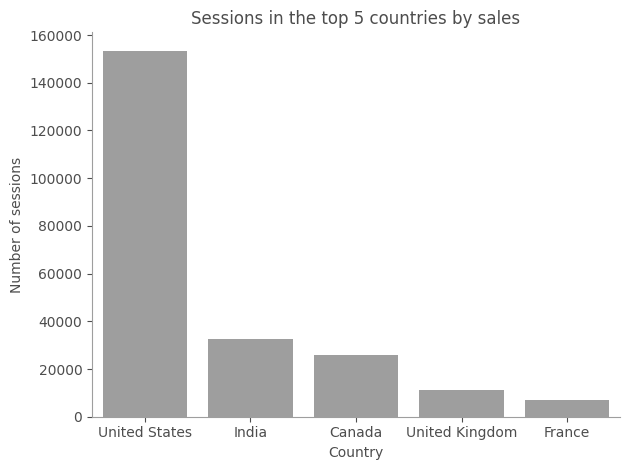

In [176]:
country_conversion_summary = countries_info[
    ["country", "sessions", "CR"]
].head(10)

display(
    country_conversion_summary.rename(
        columns={"CR": "conversion rate"}
    )
    .set_index("country")
    .style.format(
        {
            "sessions": "{:,.0f}",
            "conversion rate": "{:.2%}",
        }
    )
)

ax = sns.barplot(data=countries_info.head(5), x="country", y="sessions", color=GRAY)
ax.set_title('Sessions in the top 5 countries by sales')
ax.set_xlabel("Country")
ax.set_ylabel("Number of sessions")
plt.tight_layout()

Total sessions have a similar distribution to sales and orders. But even though the USA, India, Canada, UK and France are our leaders in sales and orders, the orders per sessions ratio is not as high, as Spain in Germany which are next in the max sales order.

The question I have now is: **Which markets underperform relative to their traffic? Which of them have the biggest financial gaps?**

#5. Business Questions

1. **Which portion of markets contributes most to the total sales and orders?** **Which portion of markets contributes almost nothing to the total sales and orders?**

2. **Which markets offer the largest opportunity to grow revenue from existing website traffic?**

#6. Deeper Analysis

##6.1 Geographical ABC-analysis:

In [177]:
countries_info['sales_cumulative'] = countries_info['sales share'].cumsum()
countries_info['orders_share'] = countries_info['orders']/total_orders
countries_info['orders_cumulative'] = countries_info['orders_share'].cumsum()

print('top 10 countries sales and orders:')
top_10_countries = countries_info[
    [
        "country",
        "sales (in millions)",
        "orders_cumulative",
        "sales_cumulative",
    ]
].head(10)
display(
    top_10_countries.rename(
        columns={
            "orders_cumulative": "orders cumulative %",
            "sales_cumulative": "sales_cumulative %",
        }
    )
    .set_index("country")
    .style.format(
        {
            "sales (in millions)": "${:,.1f}",
            "orders cumulative %": "{:.2%}",
            "sales_cumulative %": "{:.2%}",
        }
    )
)

top 10 countries sales and orders:


,sales (in millions),orders cumulative %,sales_cumulative %
country,,,
United States,$13.9,43.75%,43.61%
India,$2.8,52.78%,52.40%
Canada,$2.4,60.42%,60.03%
United Kingdom,$0.9,63.48%,62.96%
France,$0.7,65.50%,65.18%
Spain,$0.6,67.47%,67.16%
Germany,$0.6,69.38%,69.03%
China,$0.6,71.17%,70.87%
Taiwan,$0.6,72.85%,72.60%


Our top-3 countries: USA, India, Canada constitute 60.42% of total orders and 60.03% of total sales, which makes them our tier-A markets. Taking into account, that the company is represented in 107 countries (3.1.2), the tiers B and C have a very long list of countries with very little contribution to total sales and orders.


In [178]:
not_set_cumulative_share = countries_info.loc[countries_info["country"].eq("(not set)"), "sales_cumulative",].item()
print(f"(not set) country has {not_set_cumulative_share:.2%}, and so it is in B-tier. We will not consider this data in our analysis")

B_tier_countries = countries_info[(countries_info["sales_cumulative"] > 0.61) & (countries_info["sales_cumulative"] <= 0.95) ]
print("There are", B_tier_countries.shape[0] - 1, "countries that contribute between 65.5% and 95% of cumulative sales.")

C_tier_countries = countries_info[countries_info["sales_cumulative"] > 0.95]
print("There are", C_tier_countries.shape[0], "countries that contribute to the last 5% of cumulative sales.")

(not set) country has 86.38%, and so it is in B-tier. We will not consider this data in our analysis
There are 36 countries that contribute between 65.5% and 95% of cumulative sales.
There are 68 countries that contribute to the last 5% of cumulative sales.


There are 36 countries that belong to B-tier market.


**There are 68 countries that belong to the C tier in sales. We may consider the ROI in these countries before investing.**

## 6.2. Market Opportunity Matrix

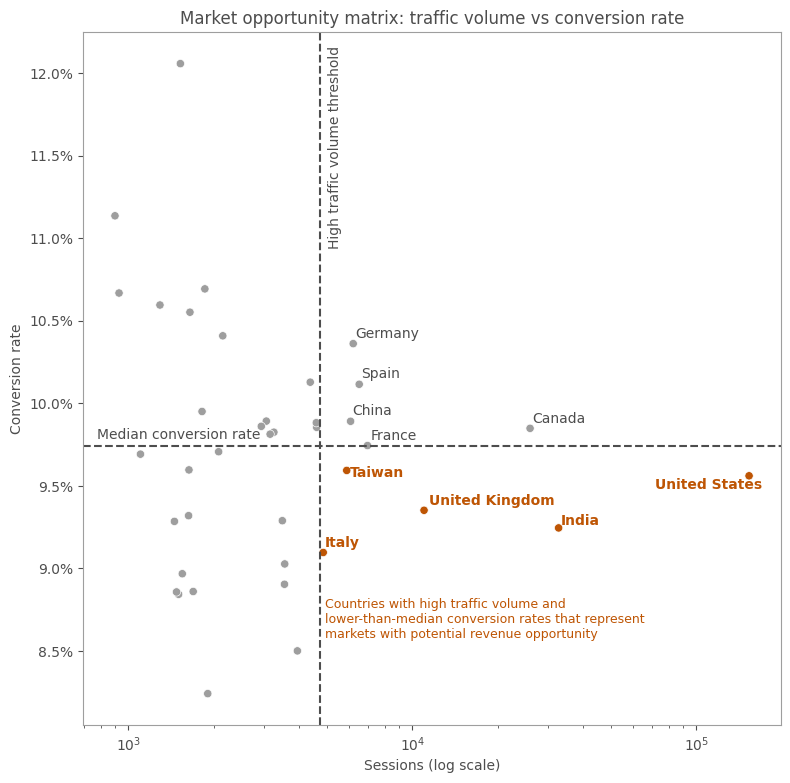

In [179]:
from adjustText import adjust_text
import numpy as np

AB_tier_countries = countries_info[(countries_info["sales_cumulative"] <= 0.95) & (countries_info['country'] != '(not set)')]
potential_markets = AB_tier_countries.sort_values(by='sessions', ascending=False, ignore_index=True)

country_sessions_Q3 = AB_tier_countries['sessions'].quantile(0.75) # high-volume countries
country_rate_median = AB_tier_countries['CR'].median() #lower-than-median converting countries

potential_markets['potential'] = (potential_markets['sessions'] > country_sessions_Q3) & (potential_markets['CR'] < country_rate_median)
#print(AB_tier_countries['sessions'])

fig, ax = plt.subplots(figsize=(9,9))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(GRAY)

sns.scatterplot(
    data=potential_markets,
    x='sessions',
    y='CR',
    hue='potential',
    palette={False: GRAY, True: ORANGE},
    ax=ax,
    legend=False,
)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda conversion_rate, _: f"{conversion_rate:.1%}")
)

ax.set_xscale('log')

ax.set_ylabel("Conversion rate")

ax.set_title('Market opportunity matrix: traffic volume vs conversion rate')
ax.set_xlabel('Sessions (log scale)')
ax.set_ylabel("Conversion rate")

ax.axvline(
    x=country_sessions_Q3,
    color=DARK_GRAY,
    linestyle='--',
)
ax.axhline(
    y=country_rate_median,
    color=DARK_GRAY,
    linestyle='--',
)

ax.annotate(
    'High traffic volume threshold',
    xy=(country_sessions_Q3, 0.98),
    xycoords=ax.get_xaxis_transform(),
    xytext=(6, 0),
    textcoords='offset points',
    rotation=90,
    ha='left',
    va='top',
    color=DARK_GRAY,
)
ax.annotate(
    'Median conversion rate',
    xy=(0.02, country_rate_median),
    xycoords=ax.get_yaxis_transform(),
    xytext=(0, 3),
    textcoords='offset points',
    ha='left',
    va='bottom',
    color=DARK_GRAY,
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# horizontal line
h_x = np.geomspace(xmin, xmax, 300)
h_y = np.full_like(h_x, country_rate_median)

# vertical line
v_y = np.linspace(ymin, ymax, 300)
v_x = np.full_like(v_y, country_sessions_Q3)

# combine both
line_x_samples = np.concatenate([h_x, v_x])
line_y_samples = np.concatenate([h_y, v_y])

texts = []

for _, row in potential_markets[potential_markets["sessions"] > country_sessions_Q3].iterrows():
    bottom_right = (
        row["sessions"] > country_sessions_Q3 and
        row["CR"] < country_rate_median
    )
    texts.append(
        ax.text(
            row['sessions'],
            row['CR'],
            row['country'],
            color=ORANGE if bottom_right else DARK_GRAY,
            fontweight='bold' if bottom_right else 'normal',
        )
    )

adjust_text(texts, ax=ax, x=line_x_samples, y=line_y_samples, expand=(1.1, 1.3));

opportunity_quadrant_countries = set(
    potential_markets.loc[potential_markets['potential'], 'country']
)

note_x =  country_sessions_Q3 + 200
note_y = country_rate_median - 0.62 * (country_rate_median - ymin)
ax.text(
    note_x,
    note_y,
    'Countries with high traffic volume and\n'
    'lower-than-median conversion rates that represent\n'
    'markets with potential revenue opportunity',
    ha='left',
    va='center',
    color=ORANGE,
    fontsize=9,
);

There are 2 clusters: several high-volume traffic countries and lower performing ones, that are roughly separated by the 75% threshold (High traffic volume threshold). Among the top 25% by volume there are 5 countries that have conversion rate lower than the median: USA, India, United Kingdom, Taiwan, Italy.

To get a clearer picture of where we potentially lose revenue due to countries underperforming in terms of their conversion rate I will analyze the revenue opportunities and then the statistical significance of the A and B tier countries underperformance.

##6.3 Revenue opportunities for underperforming countries in 3 business scenarios

Using median among the countries from A and B tiers we can calculate the base modeled revenue opportunity. I included two more scenarios: conservative scenario (Q1 as a benchmark),  and stretch scenario (Q3 as a benchmark). They provide additional infromation about how sensitive the corresponding market is to changes in conversion rates.

The calculations below have exploratory nature, and therefore use following assumptions for simplicity of the estimates:
1. They give us modeled additional revenue that we could get in 3 month, if the conversion rate (CR) was equal to the corresponding benchmark.
2. They are calculated using the formula `[sessions] * [CR_benchmark - CR] * [AOV]` (in case when CR_benchmark is less than country's CR the revenue is estimated to be 0).
3. Average order value is calculated based on these three months only. Its change wasn't taken into account here.

In [180]:
country_pool =  AB_tier_countries.copy()
print('To estimate the revenue opportunities we will use the following business benchmarks:')
benchmark_CR = country_pool['CR'].median() # we use median of AB countries as our base revenue benchmark
print(f'Base benchmark for conversion rate: {benchmark_CR * 100:.2f} % - median of the A and B tiered countries.')
conservative_CR = country_pool['CR'].quantile(0.25) # we use Q1 of AB countries as our conservative benchmark
print(f'Conservative benchmark for conversion rate: {conservative_CR * 100:.2f} %  - the first quartile of the A and B tiered countries.')
stretch_CR = country_pool['CR'].quantile(0.75) # we use Q3 of AB countries as our stretch benchmark
print(f'Stretch benchmark for conversion rate: {stretch_CR * 100:.2f} % - the third quartile of the A and B tiered countries.')
opportunity_table = country_pool.copy()
opportunity_table['CR gap'] = (benchmark_CR - opportunity_table['CR'] ).clip(lower=0)
opportunity_table['orders opportunity'] = opportunity_table['CR gap'] * opportunity_table['sessions']
opportunity_table['base scenario'] = opportunity_table['orders opportunity'] * opportunity_table['AOV']
opportunity_table['conservative scenario'] = (conservative_CR - opportunity_table['CR'] ).clip(lower=0) * opportunity_table['sessions'] * opportunity_table['AOV']
opportunity_table['stretch scenario'] = (stretch_CR - opportunity_table['CR'] ).clip(lower=0) * opportunity_table['sessions'] * opportunity_table['AOV']
opportunity_table= opportunity_table.sort_values('base scenario', ascending=False)



display(
    opportunity_table[['country','CR', 'CR gap','orders', 'orders opportunity', 'AOV', 'base scenario', 'conservative scenario', 'stretch scenario']].set_index('country').style
      .format({
          'base scenario': "${:,.2f}",
          'orders opportunity': "{:.1f}",
          'AOV': "{:.2f}",
          'conservative scenario': "${:,.2f}",
          'stretch scenario': "${:,.2f}",
          "CR": "{:.2%}",
          "CR gap": "{:.2%}",
          "p-value": "{:.4f}",
          "95% confidence interval": lambda interval: f"({interval[0]:.2%}, {interval[1]:.2%})",
      })
)
print('Total base modeled revenue:', f"{opportunity_table['base scenario'].sum():,.2f}")
print('In different scenarious: from', f"{opportunity_table['conservative scenario'].sum():,.2f}", "to", f"{opportunity_table['stretch scenario'].sum():,.2f}")


To estimate the revenue opportunities we will use the following business benchmarks:
Base benchmark for conversion rate: 9.74 % - median of the A and B tiered countries.
Conservative benchmark for conversion rate: 9.26 %  - the first quartile of the A and B tiered countries.
Stretch benchmark for conversion rate: 10.03 % - the third quartile of the A and B tiered countries.


,CR,CR gap,orders,orders opportunity,AOV,base scenario,conservative scenario,stretch scenario
country,,,,,,,,
United States,9.56%,0.18%,14673,281.4,950.29,"$267,403.08",$0.00,"$688,487.88"
India,9.25%,0.50%,3029,163.5,927.62,"$151,652.46","$6,009.44","$239,402.12"
Netherlands,8.50%,1.24%,335,49.0,914.41,"$44,822.89","$27,553.16","$55,227.87"
United Kingdom,9.35%,0.39%,1029,43.2,911.87,"$39,349.22",$0.00,"$68,318.47"
Italy,9.10%,0.65%,442,31.5,896.48,"$28,211.79","$7,337.05","$40,788.78"
Turkey,8.90%,0.84%,316,29.8,944.73,"$28,172.71","$12,105.17","$37,853.37"
Sweden,8.24%,1.50%,157,28.6,971.01,"$27,796.61","$18,932.14","$33,137.43"
Ukraine,9.03%,0.72%,321,25.5,934.72,"$23,838.25","$7,909.55","$33,435.26"
Philippines,8.86%,0.88%,150,15.0,1129.25,"$16,903.70","$7,741.86","$22,423.70"


Total base modeled revenue: 711,293.14
In different scenarious: from 104,781.45 to 1,480,378.23


In total our base estimation for countries would give us 474 thousand dollars, and under other business scenarios it could span from 99K to 850K. IN the next segment we will identify the countries that are most likely to be underperforming among other countries from A and B tiers.

##6.4 Statistical evidence for countries conversion rate underperformance and estimated revenue opportunities

In [181]:
from statsmodels.stats.proportion import confint_proportions_2indep, proportions_ztest
from statsmodels.stats.multitest import multipletests

total_orders = country_pool['orders'].sum()
total_sessions = country_pool['sessions'].sum()

# we will use the total orders to total sessions of the rest of the countries proportion as our statistical benchmark
opportunity_table['rest CR'] = ((total_orders - opportunity_table['orders']) / (total_sessions - opportunity_table['sessions']))
opportunity_table['CR difference'] = opportunity_table['CR'] - opportunity_table['rest CR']

def country_vs_rest_statistics(row):
  rest_orders = country_pool['orders'].sum() - row['orders']
  rest_sessions = country_pool['sessions'].sum() - row['sessions']

  _, p_value = proportions_ztest(
      count=np.array([row['orders'], rest_orders]),
      nobs=np.array([row['sessions'], rest_sessions]),
      alternative='smaller',
  )

  confidence_interval = confint_proportions_2indep(
      count1=row['orders'],
      nobs1=row['sessions'],
      count2=rest_orders,
      nobs2=rest_sessions,
      method='newcomb',
      compare='diff',
      alpha=0.05,
  )

  return pd.Series(
      {
          'p-value': p_value,
          '95% confidence interval': confidence_interval,
          'statistical significance' : 'significant' if p_value <0.05 else 'not significant'
      }
  )

opportunity_table[['p-value', '95% confidence interval', 'separate statistical significance']] = opportunity_table.apply(country_vs_rest_statistics, axis=1)

def statistical_revenue_opportunity(row):
    ci_low, ci_high = row['95% confidence interval']

    revenue_multiplier = row['sessions'] * row['AOV']

    base_gap = max(row['rest CR'] - row['CR'], 0)
    lowest_gap = max(-ci_high, 0)
    highest_gap = max(-ci_low, 0)

    return pd.Series({
        'lowest revenue opportunity': lowest_gap * revenue_multiplier,
        'base revenue opportunity': base_gap * revenue_multiplier,
        'highest revenue opportunity': highest_gap * revenue_multiplier,
    })
opportunity_table[['lowest revenue opportunity', 'base revenue opportunity', 'highest revenue opportunity']] = opportunity_table.apply(statistical_revenue_opportunity, axis=1)
opportunity_table['adjusted p-value'] = multipletests(opportunity_table['p-value'], method='fdr_bh')[1]
opportunity_table['multi-test significance'] = opportunity_table['adjusted p-value'].apply(
  lambda p: "yes" if p < 0.05
  else "no"
)
opportunity_table = opportunity_table.sort_values(by='base revenue opportunity', ascending=False)

display(
    opportunity_table[opportunity_table['CR gap'] > 0][['country','CR', 'rest CR', 'CR difference','95% confidence interval', 'base revenue opportunity', 'lowest revenue opportunity', 'highest revenue opportunity', 'separate statistical significance', 'multi-test significance', 'adjusted p-value']].set_index('country').style
      .format({
          "CR": "{:.2%}",
          "rest CR": "{:.2%}",
          'orders opportunity': "{:.1f}",
          'lowest revenue opportunity': "${:,.0f}",
          'base revenue opportunity': "${:,.0f}",
          'highest revenue opportunity': "${:,.0f}",
          'AOV': "{:.2f}",
          "CR difference": "{:.2%}",
          "CR gap": "{:.2%}",
          "p-value": "{:.4f}",
          "adjusted p-value": "{:.4f}",
          "95% confidence interval": lambda interval: f"({interval[0]:.2%}, {interval[1]:.2%})",
      })
)

print('Base revenue:', opportunity_table['base revenue opportunity'].sum())

,CR,rest CR,CR difference,95% confidence interval,base revenue opportunity,lowest revenue opportunity,highest revenue opportunity,separate statistical significance,multi-test significance,adjusted p-value
country,,,,,,,,,,
India,9.25%,9.63%,-0.39%,"(-0.71%, -0.05%)","$117,836","$15,849","$217,174",significant,no,0.2317
United States,9.56%,9.62%,-0.06%,"(-0.26%, 0.14%)","$91,450",$0,"$385,652",not significant,no,0.8140
Netherlands,8.50%,9.61%,-1.11%,"(-1.94%, -0.19%)","$39,898","$6,844","$70,062",significant,no,0.2317
Sweden,8.24%,9.60%,-1.36%,"(-2.52%, -0.04%)","$25,169",$671,"$46,569",significant,no,0.2884
United Kingdom,9.35%,9.60%,-0.25%,"(-0.79%, 0.32%)","$25,146",$0,"$79,311",not significant,no,0.7112
Turkey,8.90%,9.60%,-0.70%,"(-1.60%, 0.29%)","$23,398",$0,"$53,536",not significant,no,0.7112
Italy,9.10%,9.60%,-0.51%,"(-1.29%, 0.34%)","$22,005",$0,"$56,123",not significant,no,0.7112
Ukraine,9.03%,9.60%,-0.57%,"(-1.48%, 0.42%)","$19,060",$0,"$49,106",not significant,no,0.7112
Philippines,8.86%,9.60%,-0.74%,"(-2.00%, 0.71%)","$14,110",$0,"$38,317",not significant,no,0.7112


Base revenue: 431726.0300787632


Among the separate proportion tests three countries showed statistically significant underperfomance with 95% confidence: India, Netherlands and Sweden. After correcting for a multi-test none of the countries showed statistically significant underperformance.

95% confidence intervals of separate proportion tests show base revenue to be in 380K total, most of which come from India.

##6.5 Modeled potential revenue and the evidence of underperformance

In the previous segment we saw that India, Netherlands and Sweden passed the separate proportion tests with 95% confidence level. However, after accounting for multiple testing none of the countries had enough evidence of underperformance.

In the bar plot below you can see which countries passed the test and what is their estimated revenue computed using median conversion rate benchmark we introduced in 6.3

The countries that are marked orange are the countries in the top 25% by traffic volume (first introduced in 6.2)

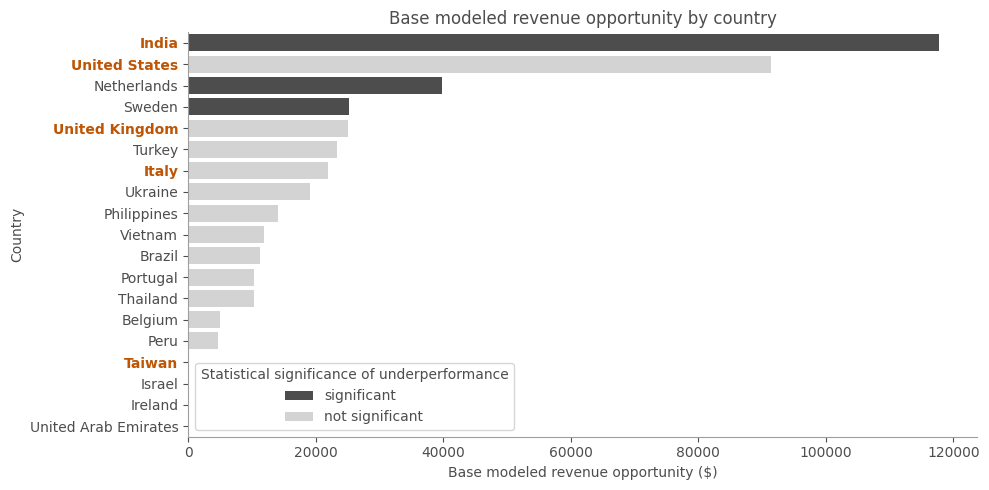

In [182]:
fig, ax = plt.subplots(figsize=(10,5))
fig = sns.barplot(
    data=opportunity_table[opportunity_table['CR gap'] > 0],
    x='base revenue opportunity',
    y='country',
    hue='separate statistical significance',
    hue_order=['significant', 'not significant'],
    palette={
        'significant': DARK_GRAY,
        'not significant': LIGHT_GRAY,
    },
)
fig.set_title('Base modeled revenue opportunity by country')
fig.set_xlabel('Base modeled revenue opportunity ($)')
fig.set_ylabel('Country')
fig.legend(title='Statistical significance of underperformance')

# Orange country names link section 6.5 back to the opportunity quadrant in 6.2.
for country_label in fig.get_yticklabels():
    if country_label.get_text() in opportunity_quadrant_countries:
        country_label.set_color(ORANGE)
        country_label.set_fontweight('bold')
plt.tight_layout()

**In this chart I show our biggest revenue opportunity alongside with statistical significance of underperfomance for separate tests (after adjusting for multi-testing none of teh countries showed statistically significant underperformance ). India has the highest opportunity and highest evidence of underperforming. Netherlands is our second biggest opportunity market with second highest evidence of underperformance. Even though United States show the biggest revenue opportunity, the reason for that is the outstanding traffic volume, not a particulary big conversion rate gap. The separate proportion test for US did not show a statistically significant evidence of underperformance.**

Among other interesting opportunities are United Kingdom and Italy. Underperformance of these countries is not as likely, but they are among top 25% traffic volume countries and therefore are potentially worth futher investigation.

Sweden is another country worth exploring: its revenue opportunity is not as high as other countries mentioned, but this country also showed statistically significant separate evidence.

##6.6 India & Netherlands underperformance investigation

In this section we investigate conversion rate and modeled revenue opportunity by traffic channels and device for India and Netherlands.
It does not provide evidence that would indicate that this improvement is realistic, but rather provides direction for further exploration.

###6.3.1 Sales, sessions, orders and conversion rate across all countries by traffic channel

In this section we gather general infromation of traffic dictribution across traffic channels:

The top performer by sales  and sessions is **Organic search (11.4M $$, 35.76 % of sales)**, followed by **Paid Search (8.5M $, 26.62 % of sales)** and **Direct (7.5M $, 23.44 % of sales)**. Social Search and Undefined channels perform significantly worse.
The conversion rates are very stable across channel.

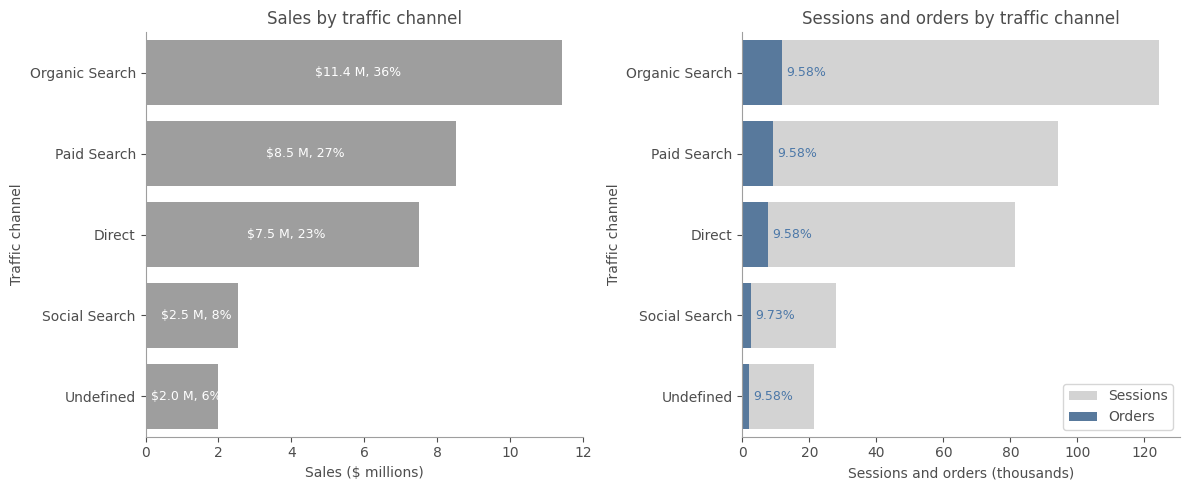

In [183]:
traffic_info = (
    data.groupby(["traffic_channel", "country"], as_index=False)
        .agg(
            sessions=("ga_session_id", "count"),
            orders=("item_id", "count"),
            sales=("price", "sum"),
        )
)

traffic_info_general = traffic_info.groupby('traffic_channel')[['sessions', 'orders', 'sales']].sum().reset_index()
traffic_info_general['share_orders'] = traffic_info_general['orders']/traffic_info_general['sessions']
traffic_info_general = traffic_info_general.sort_values(by='sessions', ascending=False)

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=traffic_info_general, x="sales", y="traffic_channel", ax=axes[0], color=GRAY)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}'))
axes[0].set_title('Sales by traffic channel')
axes[0].set_xlabel('Sales ($ millions)')
axes[0].set_ylabel('Traffic channel')
axes[0].bar_label(
    axes[0].containers[0],
    labels=[f'${p/1e6:,.1f} M, {p/traffic_info_general['sales'].sum():.0%}' for p in traffic_info_general['sales']],
    padding=3, fontsize=9, color="white",
     label_type='center',
)

sns.barplot(data=traffic_info_general, x="sessions", y="traffic_channel", ax=axes[1], label='Sessions', color=LIGHT_GRAY)
sns.barplot(data=traffic_info_general, x="orders", y="traffic_channel", ax=axes[1], label='Orders', color=BLUE)
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e3:.0f}'))
axes[1].set_title('Sessions and orders by traffic channel')
axes[1].set_xlabel('Sessions and orders (thousands)')
axes[1].set_ylabel('Traffic channel')
axes[1].bar_label(
    axes[1].containers[1],
    labels=[f'{p:.2%}' for p in traffic_info_general['share_orders']],
    padding=3, fontsize=9, color=BLUE
)
plt.tight_layout()

The top performer by sales and sessions is Organic search, followed by paid search and direct. Social Search and Undefined channels perform significantly worse.

The conversion rates are very stable across channel.

###6.3.2 India's modeled revenue by traffic channel. Comparing India and median conversion rate.

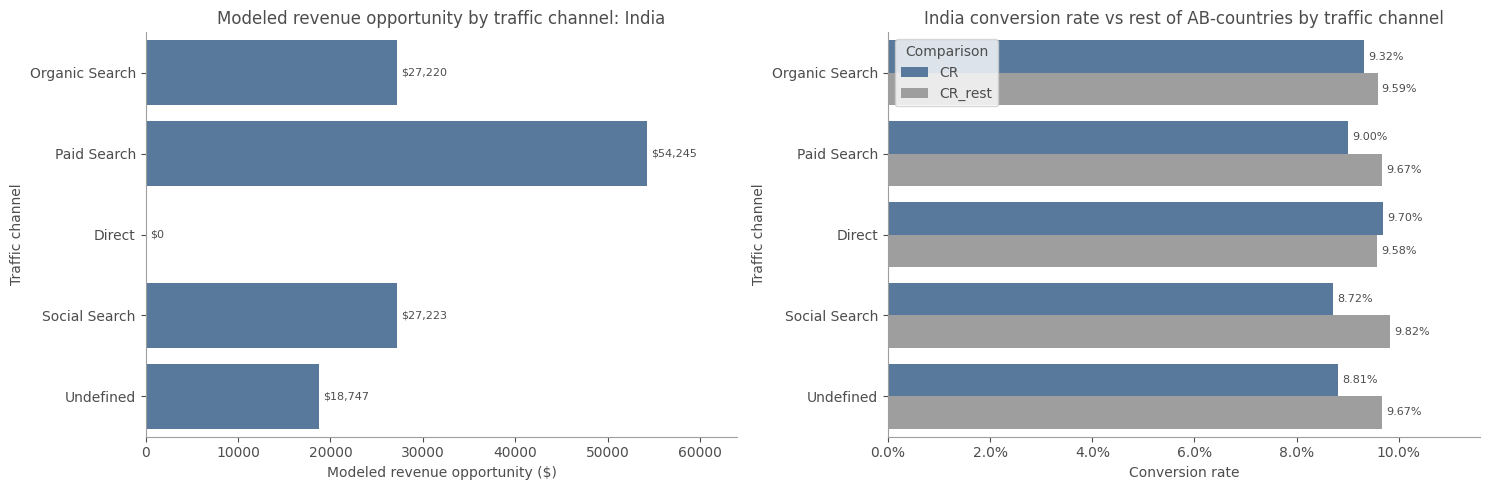

In [184]:
comparison_countries = ['India', 'Netherlands']

traffic_info['AOV'] = traffic_info['sales']/traffic_info['orders']
traffic_info['CR'] = traffic_info['orders'] / traffic_info['sessions']
sessions_per_channel = traffic_info[(traffic_info['country'].isin(country_pool['country']))].groupby('traffic_channel')[['sessions', 'orders']].sum()
traffic_comparison = traffic_info[traffic_info['country'].isin(country_pool['country'])].copy()
traffic_comparison = traffic_comparison.merge(sessions_per_channel, how='left', on='traffic_channel', suffixes=['_country', '_all'])
traffic_comparison['CR_rest'] = (traffic_comparison['orders_all'] - traffic_comparison['orders_country']) / (traffic_comparison['sessions_all'] - traffic_comparison['sessions_country'])
traffic_comparison['revenue opportunity'] = (traffic_comparison['sessions_country'] * (traffic_comparison['CR_rest'] -traffic_comparison['CR']  )* traffic_comparison['AOV']).clip(lower=0)

plot_India = traffic_comparison.loc[traffic_comparison["country"].eq("India")].melt(
    id_vars="traffic_channel",
    value_vars=["CR", "CR_rest"],
    var_name="metric",
    value_name="Comparison",
)


traffic_channel_order = (
    traffic_info.groupby('traffic_channel')['sales']
        .sum()
        .sort_values(ascending=False)
        .index
)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=traffic_comparison[traffic_comparison['country']=='India'],
    y='traffic_channel',
    x='revenue opportunity',
    order=traffic_channel_order,
    color=BLUE,
    ax=axes[0],
)
sns.barplot(
    data=plot_India,
    y='traffic_channel',
    x='Comparison',
    hue='metric',
    hue_order=['CR', 'CR_rest'],
    palette={'CR': BLUE, 'CR_rest': GRAY},
    order=traffic_channel_order,
    ax=axes[1],
)

for container in axes[0].containers:
    labels = [f'${value:,.0f}' if pd.notna(value) else '' for value in container.datavalues]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=8)
for container in axes[1].containers:
    labels = [f'{value:.2%}' if pd.notna(value) else '' for value in container.datavalues]
    axes[1].bar_label(container, labels=labels, padding=3, fontsize=8)
axes[0].margins(x=0.18)
axes[1].margins(x=0.18)
axes[0].set_title('Modeled revenue opportunity by traffic channel: India')
axes[1].set_title('India conversion rate vs rest of AB-countries by traffic channel')
axes[0].set_xlabel('Modeled revenue opportunity ($)')
axes[1].set_xlabel('Conversion rate')
axes[0].set_ylabel('Traffic channel')
axes[1].set_ylabel('Traffic channel')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1%}'))
axes[1].legend(title='Comparison')
plt.tight_layout()
plt.show()

 The biggest modeled revenue lie in Paid Searh traffic channel gap: 54.245 K . Organic search and Social Search have the next biggest revenue opportunity: about 27$K.

###6.3.3 Netherlands' modeled revenue by traffic channel. Comparing Netherlands and median conversion rate.

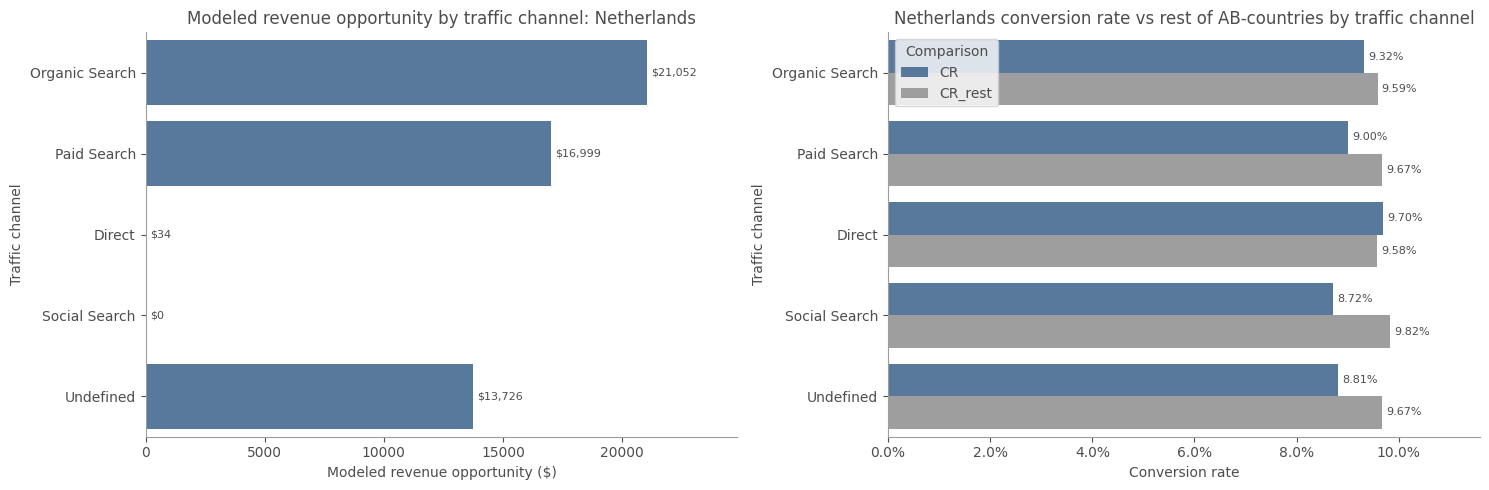

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=traffic_comparison[traffic_comparison['country']=='Netherlands'],
    y='traffic_channel',
    x='revenue opportunity',
    color=BLUE,
    order=traffic_channel_order,
    ax=axes[0],
)
sns.barplot(
    data=plot_India,
    y='traffic_channel',
    x='Comparison',
    hue='metric',
    hue_order=['CR', 'CR_rest'],
    palette={'CR': BLUE, 'CR_rest': GRAY},
    order=traffic_channel_order,
    ax=axes[1],
)

for container in axes[0].containers:
    labels = [f'${value:,.0f}' if pd.notna(value) else '' for value in container.datavalues]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=8)
for container in axes[1].containers:
    labels = [f'{value:.2%}' if pd.notna(value) else '' for value in container.datavalues]
    axes[1].bar_label(container, labels=labels, padding=3, fontsize=8)
axes[0].margins(x=0.18)
axes[1].margins(x=0.18)
axes[0].set_title('Modeled revenue opportunity by traffic channel: Netherlands')
axes[1].set_title('Netherlands conversion rate vs rest of AB-countries by traffic channel')
axes[0].set_xlabel('Modeled revenue opportunity ($)')
axes[1].set_xlabel('Conversion rate')
axes[0].set_ylabel('Traffic channel')
axes[1].set_ylabel('Traffic channel')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1%}'))
handles, labels = axes[1].get_legend_handles_labels()
labels = [
    'AB countries\naverage' if label == 'AB countries average' else label
    for label in labels
]
axes[1].legend(handles, labels, title='Comparison')
plt.tight_layout()
plt.show()

Biggest revenue opportunity is an Organic Search traffic channel 21.0K, followed by Paid search it's about 17K. Social Search channel has much higher conversion rate than in the rest AB countries.

###6.3.4. Sales, sessions, orders and conversion rate across all countries by devices


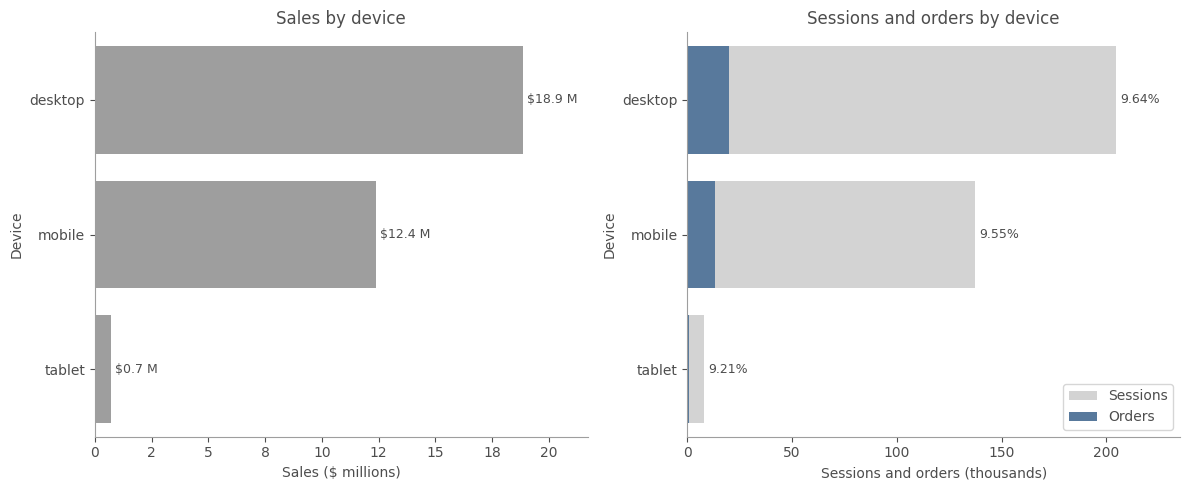

In [186]:
comparison_countries = ['India', 'Netherlands']

device_info = (
    data.groupby(['device', 'country'], as_index=False)
        .agg(
            sessions=('ga_session_id', 'count'),
            orders=('item_id', 'count'),
            sales=('price', 'sum'),
        )
)
device_info['CR'] = device_info['orders'] / device_info['sessions']
device_info['AOV'] = (
    device_info['sales'] / device_info['orders']
).where(device_info['orders'] > 0)
device_info['revenue opportunity'] = (
    device_info['sessions']
    * (benchmark_CR - device_info['CR'])
    * device_info['AOV']
).clip(lower=0)

device_info_general = (
    device_info.groupby('device', as_index=False)[['sessions', 'orders', 'sales']]
        .sum()
        .sort_values(by='sessions', ascending=False)
)
device_info_general['CR'] = (
    device_info_general['orders'] / device_info_general['sessions']
)
device_order = device_info_general['device'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=device_info_general,
    x='sales',
    y='device',
    order=device_order,
    ax=axes[0],
    color=GRAY,
)
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.0f}')
)
axes[0].set_title('Sales by device')
axes[0].set_xlabel('Sales ($ millions)')
axes[0].set_ylabel('Device')
axes[0].bar_label(
    axes[0].containers[0],
    labels=[f'${value/1e6:,.1f} M' for value in device_info_general['sales']],
    padding=3,
    fontsize=9,
)

sns.barplot(
    data=device_info_general,
    x='sessions',
    y='device',
    order=device_order,
    ax=axes[1],
    label='Sessions',
    color=LIGHT_GRAY,
)
sns.barplot(
    data=device_info_general,
    x='orders',
    y='device',
    order=device_order,
    ax=axes[1],
    label='Orders',
    color=BLUE,
)
axes[1].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e3:.0f}')
)
axes[1].set_title('Sessions and orders by device')
axes[1].set_xlabel('Sessions and orders (thousands)')
axes[1].set_ylabel('Device')
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f'{value:.2%}' for value in device_info_general['CR']],
    padding=3,
    fontsize=9,
)
axes[1].legend()
for ax in axes:
    ax.margins(x=0.15)
plt.tight_layout()
plt.show()


Desktop and mobile device have much bigger sales and sessions share, with desktop leading. The conversion rate is stable across all three device categories.

###6.3.5 India's modeled revenue by traffic channel. Comparing India and median conversion rate.

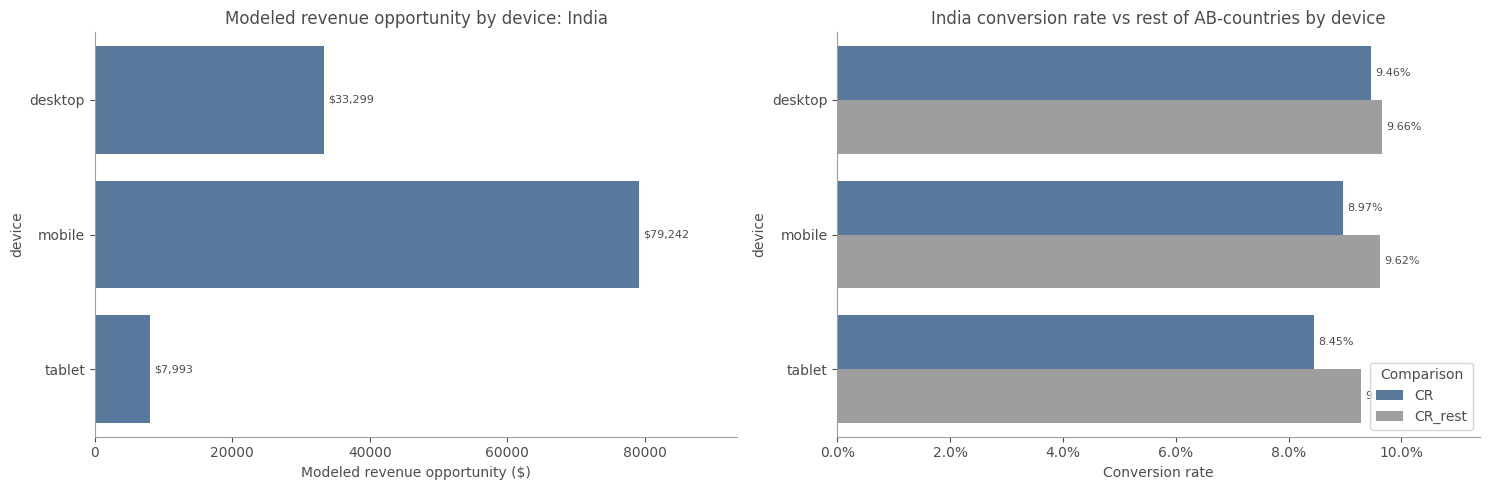

In [187]:
device_info['AOV'] = device_info['sales']/device_info['orders']
device_info['CR'] = device_info['orders'] / device_info['sessions']
sessions_per_device = device_info[(device_info['country'].isin(country_pool['country']))].groupby('device')[['sessions', 'orders']].sum()
device_comparison = device_info[device_info['country'].isin(country_pool['country'])].copy()
device_comparison = device_comparison.merge(sessions_per_device, how='left', on='device', suffixes=['_country', '_all'])
device_comparison['CR_rest'] = (device_comparison['orders_all'] - device_comparison['orders_country']) / (device_comparison['sessions_all'] - device_comparison['sessions_country'])
device_comparison['revenue opportunity'] = (device_comparison['sessions_country'] * (device_comparison['CR_rest'] -device_comparison['CR']  )* device_comparison['AOV']).clip(lower=0)

plot_India = device_comparison.loc[device_comparison["country"].eq("India")].melt(
    id_vars="device",
    value_vars=["CR", "CR_rest"],
    var_name="metric",
    value_name="Comparison",
)


device_order = (
    device_info.groupby('device')['sales']
        .sum()
        .sort_values(ascending=False)
        .index
)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=device_comparison[device_comparison['country']=='India'],
    y='device',
    x='revenue opportunity',
    order=device_order,
    color=BLUE,
    ax=axes[0],
)
sns.barplot(
    data=plot_India,
    y='device',
    x='Comparison',
    hue='metric',
    hue_order=['CR', 'CR_rest'],
    palette={'CR': BLUE, 'CR_rest': GRAY},
    order=device_order,
    ax=axes[1],
)

for container in axes[0].containers:
    labels = [f'${value:,.0f}' if pd.notna(value) else '' for value in container.datavalues]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=8)
for container in axes[1].containers:
    labels = [f'{value:.2%}' if pd.notna(value) else '' for value in container.datavalues]
    axes[1].bar_label(container, labels=labels, padding=3, fontsize=8)
axes[0].margins(x=0.18)
axes[1].margins(x=0.18)
axes[0].set_title('Modeled revenue opportunity by device: India')
axes[1].set_title('India conversion rate vs rest of AB-countries by device')
axes[0].set_xlabel('Modeled revenue opportunity ($)')
axes[1].set_xlabel('Conversion rate')
axes[0].set_ylabel('device')
axes[1].set_ylabel('device')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1%}'))
axes[1].legend(title='Comparison')
plt.tight_layout()
plt.show()

In India mobile devices have  the biggest CR gap and modeled revenue opportunity - 79.2K, than desktop - about 33.3K, even though desktop devices have bigger traffic in general.

###6.3.6 Netherlands' modeled revenue by devices. Comparing Netherlands and median conversion rate.

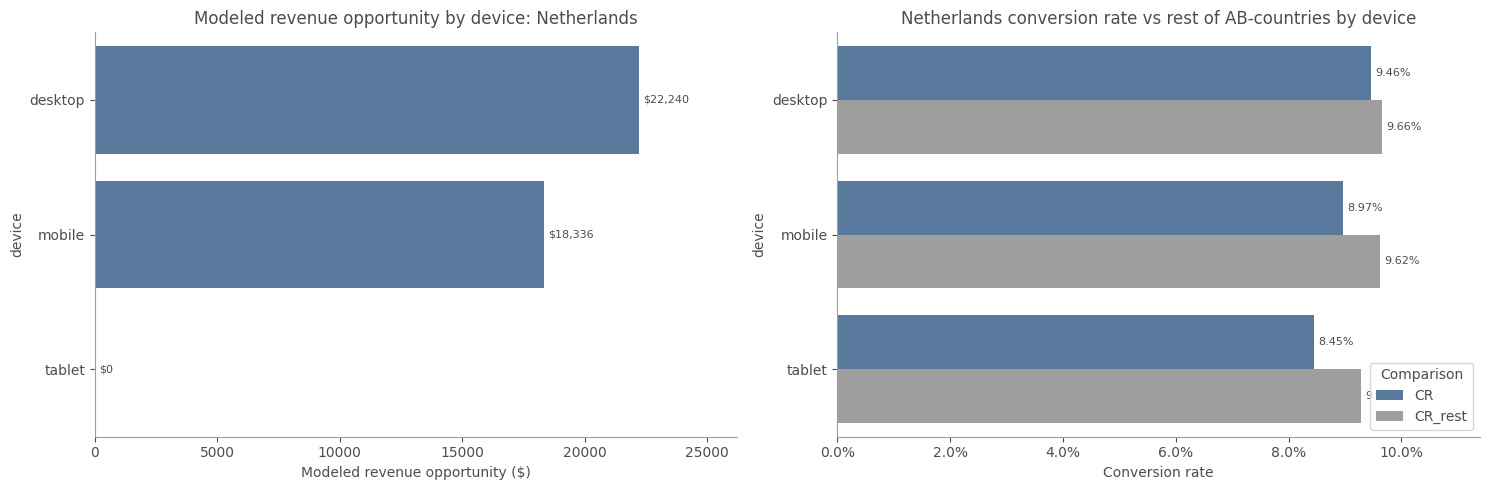

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=device_comparison[device_comparison['country']=='Netherlands'],
    y='device',
    x='revenue opportunity',
    color=BLUE,
    order=device_order,
    ax=axes[0],
)
sns.barplot(
    data=plot_India,
    y='device',
    x='Comparison',
    hue='metric',
    hue_order=['CR', 'CR_rest'],
    palette={'CR': BLUE, 'CR_rest': GRAY},
    order=device_order,
    ax=axes[1],
)

for container in axes[0].containers:
    labels = [f'${value:,.0f}' if pd.notna(value) else '' for value in container.datavalues]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=8)
for container in axes[1].containers:
    labels = [f'{value:.2%}' if pd.notna(value) else '' for value in container.datavalues]
    axes[1].bar_label(container, labels=labels, padding=3, fontsize=8)
axes[0].margins(x=0.18)
axes[1].margins(x=0.18)
axes[0].set_title('Modeled revenue opportunity by device: Netherlands')
axes[1].set_title('Netherlands conversion rate vs rest of AB-countries by device')
axes[0].set_xlabel('Modeled revenue opportunity ($)')
axes[1].set_xlabel('Conversion rate')
axes[0].set_ylabel('device')
axes[1].set_ylabel('device')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1%}'))
handles, labels = axes[1].get_legend_handles_labels()
labels = [
    'AB countries\naverage' if label == 'AB countries average' else label
    for label in labels
]
axes[1].legend(handles, labels, title='Comparison')
plt.tight_layout()
plt.show()

In Netherlands the biggest CR gap and modeled revenue opportunity are for desktop devices - 22,2K and for mobile devices 18.3K

##6.7 Data quality concern

The "(not set)", unknown country had 290 orders and 0.83% of total sales. This could be a point of investigation - why it is not set and if we can prevent this data from being lost.

In [189]:
display(
    countries_info[countries_info['country'] == '(not set)'][['country', 'sessions', 'orders','sales', 'sales share']].set_index('country').style
      .format({
          "sales": "${:,.0f}",
          "sales share": "{:.2%}",
      })
)

,sessions,orders,sales,sales share
country,,,,
(not set),2808,290,"$266,847",0.83%


#7. Summary

##7.1 Conclusions

Having made geo analysis of the website I have come to the following conclusions:
1. Among 107 countries our business spans there are 3 countries contributing to 60% of sales and orders, 36 countries contributing to 35% more and 68 countries contributing to only 5% that is left. This long tail of C-tier countries are worth reviewing in terms of return of investment, as this data does not have any information on the costs.
2. As a result of conversion rate underperfomance analysis India turned out to be the country with the highest modeled revenue opportunity as well as highest evidence of underperformance when compared to other countries in A and B tiers: about 117K of modeled additional revenue. The next best by revenue estimation and evidence are Netherlands with about $40K of modeled revenue opportinuty.
4. I've analyzed modeled additional revenue from covering a conversion gap, and uncovered the biggest traffic channels and devices, where we potentially would like to first investigate the reasons behind the underperformance. India it's Paid search and mobile devices. For Netherlands it's Organic, Paid and Undefined traffic channels for both desktop and mobile devices.
5. Other possible candidates for conversion rate improvement are United States, United Kingdom and Italy. The evidence of underperformance of these countries is not as strong, but the modeled opportunity is in the top-4 countries.
6. In Sweden there is high relative evidence of underperformance, but lower potential revenue.

##7.2 Recommendations

1. There are 68 countries which contribute in total to 5% of income. This long list of countries should be inspected for return of investment.

2. This report signals to two priority markets, India and Netherlands, in which there is the highest revenue potential and evidence for the possible conversion rate improvement.
Therefore, I would recommend investigate the ordering process in these countries for potential revenue gaps we could cover.

3. Other potentially interesting countries for exploring the conversion rate improvement are United Kingdom, Italy and Sweden.

##7.3 Data Limitations and next steps

1. The costs per order weren't included in the data, which means that the low  return of investment for the C-tier countries is only a suggestion.
2. This report gives an estimated revenue that could be obtained in case of increasing the conversion rate of countries in A and B tiers. The underperformance of the conversion rates of the countries wasn't confirmed when the p-value was adjusted to multi-testing. Thus, the results shouldn't be interpreted with a 95% confidence level, rather they are a signal for the following investigation.

Furthermore, the conversion rate could be influenced by a lot of outside factors, that should be accounted for before the investment takes place. One of those factors is country's conversion rate ceiling. India and Italy are known for their lower than average conversion rate, and consequently their conversion gap may not be realistically possible to cover. United Kingdom, on the other hand, has one of the highest conversion rates overall and it has a good modeled revenue opportunity, so even it didn't have enough evidence of underperformance compared to the rest of the countries in A and B tier, it might underperform compared to its potential CR.

3. Among the countries' names there was a "country" named "(not set)", which contributed to 0.8% of sales and had a substantial amount of sesssions and orders. In our ABC geo analysis this entity was in a B tier, and it also spanned across multiple continents. This data quality issue is worth investigating and if possible should be addressed.

4. The data of this website has only the information about three months: November, December and January of 2020-2021. This leaves little room for adjustment over time period and estimating the calculated metrics over time. If the data was collected for a longer duration the estimation could be more precise.

5. The model we used does not account for change in average order value and conversion rates over the time. It also does not account for traffic and devices. It is only a tool for signaling the most interesting further investigations.

The next steps for this investigation would be:
1. Find out possible underlying reasons for underperformance of India and Netherlands (for this we need more data of user behaviour)
2. Form a hypothesis under which we could improve their CRs.
3. Conduct AB-test to confirm or deny the hypothesis, and analyze its results.